In [26]:
#Montar mi google drive para poder usar los archivos
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [27]:

#pip install --force-reinstall plotly

In [28]:

def antiSpace(strParam):
  result = ''
  for ch in strParam:
    if ch != ' ' and ch != ',' and ch != '/' and ch != '1':
      result = result + ch
    else:
      result = result + '_'
  return result

# 1980-2022, without emerging sources downloaded January 18 2024

Data were retrieved from InCites, a bibliometric tool for research evaluation developed by Clarivate Analytics. Annual global outputs from 1980 to 2022 across the 22 research fields defined by the Essential Science Indicators (ESI) schema were downloaded using the Analyze -> Research Areas option, selecting the Trend checkbox. Country-level outputs for each ESI area were obtained via the Analyze -> Locations menu, filtering data by area under the ESI scheme and downloading 22 separate files containing country-specific information.

In [29]:
%cd /content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/Locations2026/
!ls

/content/gdrive/.shortcut-targets-by-id/0B5aSrRJgnViLfm9LWl9TY21TWm5wSU0zbkgzc2YyeEp3RzJMaEJOR2FWbFkxVEZYTjNQd1E/Ciencias/Data/WoS/InCites/ESI/Locations2026
'Agricultural Sciences.xlsx'	  'Materials Science.xlsx'
 ai.txt				   Mathematics.xlsx
 AMEASURE.txt			   Microbiology.xlsx
'Biology & Biochemistry.xlsx'	  'Molecular Biology & Genetics.xlsx'
 Chemistry.xlsx			   Multidisciplinary.xlsx
'Clinical Medicine.xlsx'	  'Neuroscience & Behavior.xlsx'
'Computer Science.xlsx'		  'Pharmacology & Toxicology.xlsx'
'Economics & Business.xlsx'	   Physics.xlsx
 Engineering.xlsx		  'Plant & Animal Science.xlsx'
 Environment_Ecology.xlsx	   Psychiatry_Psychology.xlsx
 figuras			   rsi.txt
 FMEASURE.txt			   scatterplots
 GAggregation.txt		   scatterplots.html
 Geosciences.xlsx		   share.txt
 GMEASURE.txt			  'Social Sciences, general.xlsx'
 Immunology.xlsx		  'Space Science.xlsx'
'Incites Locations Trend.xlsx'	   Wshare.txt
 manuscriptFiguresAndTables.html


In [30]:

import pandas as pd
import numpy as np
import os
#
INDICADOR = 'Web of Science Documents'
YEAR = 'Publication Year'


In [31]:
# Read the files from the areas. IMPORTANT: Set the file names.
areas = ['Agricultural Sciences', 'Biology & Biochemistry', 'Chemistry', 'Clinical Medicine', 'Computer Science', 'Economics & Business',
         'Engineering', 'Environment/Ecology', 'Geosciences', 'Immunology', 'Materials Science', 'Mathematics', 'Microbiology',
         'Molecular Biology & Genetics', 'Multidisciplinary', 'Neuroscience & Behavior', 'Pharmacology & Toxicology', 'Physics', 'Plant & Animal Science',
         'Psychiatry/Psychology', 'Social Sciences, general', 'Space Science']

fileNames = {
              'Agricultural Sciences': 'Agricultural Sciences.xlsx',
             'Biology & Biochemistry': 'Biology & Biochemistry.xlsx',
             'Chemistry': 'Chemistry.xlsx',
             'Clinical Medicine':'Clinical Medicine.xlsx'	,
             'Computer Science':'Computer Science.xlsx',
             'Economics & Business':'Economics & Business.xlsx',
             'Engineering':'Engineering.xlsx',
             'Environment/Ecology':'Environment_Ecology.xlsx',
             'Geosciences':'Geosciences.xlsx',
             'Immunology':'Immunology.xlsx',
             'Materials Science':'Materials Science.xlsx',
             'Mathematics':'Mathematics.xlsx',
             'Microbiology':'Microbiology.xlsx',
             'Molecular Biology & Genetics':'Molecular Biology & Genetics.xlsx',
             'Multidisciplinary':'Multidisciplinary.xlsx',
             'Neuroscience & Behavior':'Neuroscience & Behavior.xlsx',
             'Pharmacology & Toxicology':'Pharmacology & Toxicology.xlsx',
             'Physics':'Physics.xlsx',
             'Plant & Animal Science':'Plant & Animal Science.xlsx',
             'Psychiatry/Psychology':'Psychiatry_Psychology.xlsx',
             'Social Sciences, general':'Social Sciences, general.xlsx',
             'Space Science':'Space Science.xlsx'
            }


df_Areas = {}
for area in areas:
  fName = fileNames[area]
  if fName != None:
    df_Areas[area] = pd.read_excel(fName, index_col=0)


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning:

Workb

In [32]:
df_Areas['Agricultural Sciences']

,Web of Science Documents,Publication Year,Rank,% Docs Cited,Category Normalized Citation Impact,% Documents in Top 1%,% Documents in Top 10%
Name,,,,,,,
Global Baseline,11688.0,1980,NaN,69.11,0.999997,0.97,9.76
Global Baseline,11303.0,1981,NaN,71.69,0.999997,0.99,9.86
Global Baseline,11826.0,1982,NaN,73.31,1.000000,0.99,9.76
Global Baseline,11725.0,1983,NaN,76.73,0.999998,0.99,9.76
Global Baseline,12002.0,1984,NaN,77.06,0.999998,0.98,9.88
...,...,...,...,...,...,...,...
TUVALU,NaN,2020,NaN,NaN,NaN,NaN,NaN
TUVALU,NaN,2021,NaN,NaN,NaN,NaN,NaN
TUVALU,NaN,2022,NaN,NaN,NaN,NaN,NaN


In [33]:
# Read the global indicators of the areas.
unitsTrend = pd.read_excel("Incites Locations Trend.xlsx", index_col=0)
unitsTrend.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning:

Workbook contains no default style, apply openpyxl's default



,Web of Science Documents,Publication Year,Rank,% Docs Cited,Category Normalized Citation Impact,% Documents in Top 1%,% Documents in Top 10%
Name,,,,,,,
Global Baseline,353862.0,1980,NaN,80.47,0.999998,0.99,9.86
Global Baseline,370671.0,1981,NaN,80.87,0.999999,0.99,9.84
Global Baseline,391103.0,1982,NaN,80.86,1.000000,0.98,9.87
Global Baseline,415313.0,1983,NaN,80.49,1.000001,0.99,9.83
Global Baseline,431578.0,1984,NaN,81.05,1.000000,0.99,9.81


In [34]:
# Generate the list of units. It is likely that all units exist in all files.
units = np.unique(df_Areas['Agricultural Sciences'].index)
units = np.unique(unitsTrend.index)

#for area in df_Areas:
#  units_temp = np.unique(df_Areas[area].index)
#  units = np.concatenate((units, units_temp), axis=None)
#units = np.unique(units)
units

array(['AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'AMERICAN SAMOA', 'ANDORRA',
       'ANGOLA', 'ANTIGUA & BARBUDA', 'ARGENTINA', 'ARMENIA', 'AUSTRALIA',
       'AUSTRIA', 'AZERBAIJAN', 'BAHAMAS', 'BAHRAIN', 'BANGLADESH',
       'BARBADOS', 'BELARUS', 'BELGIUM', 'BELIZE', 'BENIN', 'BERMUDA',
       'BHUTAN', 'BOLIVIA', 'BOSNIA & HERZEGOVINA', 'BOTSWANA', 'BRAZIL',
       'BRUNEI', 'BULGARIA', 'BURKINA FASO', 'BURUNDI',
       'Baseline for All Items', 'CAMBODIA', 'CAMEROON', 'CANADA',
       'CAPE VERDE', 'CENT AFR REPUBL', 'CHAD', 'CHILE', 'CHINA MAINLAND',
       'COLOMBIA', 'COMOROS', 'CONGO DEMOCRATIC REPUBLIC',
       'CONGO PEOPLES REP', 'COOK ISLANDS', 'COSTA RICA', 'COTE IVOIRE',
       'CROATIA', 'CUBA', 'CYPRUS', 'CZECH REPUBLIC', 'CZECHOSLOVAKIA',
       'DENMARK', 'DJIBOUTI', 'DOMINICA', 'DOMINICAN REPUBLIC', 'ECUADOR',
       'EGYPT', 'EL SALVADOR', 'ENGLAND', 'EQUATORIAL GUINEA', 'ERITREA',
       'ESTONIA', 'ESWATINI', 'ETHIOPIA', 'FIJI', 'FINLAND', 'FRANCE',
       'FRENCH GU

In [35]:
# Create a production matrix Years × Areas for each country
df_units = {}
for unit in units:
  df_units[unit] =  pd.DataFrame()
  for area in fileNames:
    if fileNames[area] != None:
      #Dataframe con los datos de la unidad en el area
      if unit in df_Areas[area].index:
        dfUnit_Area = df_Areas[area].loc[unit]

        dfAreaUnit = dfUnit_Area[[YEAR, INDICADOR]].values
        if dfAreaUnit.size > 2:
          dfAreaUnit = pd.DataFrame({YEAR:dfAreaUnit[:,0], area:dfAreaUnit[:,1]})
          dfAreaUnit = dfAreaUnit.set_index(YEAR)
          if df_units[unit].empty:
            df_units[unit] =  dfAreaUnit
          else:
            df_units[unit] = pd.merge(df_units[unit], dfAreaUnit, on=YEAR, how='outer')
  df_units[unit].fillna(0, inplace=True)
  df_units[unit].sort_index(inplace=True)

In [36]:
## Areas' production over the years
df_areas=pd.DataFrame(index=df_units[unit].index)

for area in areas: #Number of papers is at 'Baseline for All Items'
  df_areas[area] = df_units['Baseline for All Items'][area]

df_areas.head()

,Agricultural Sciences,Biology & Biochemistry,Chemistry,Clinical Medicine,Computer Science,Economics & Business,Engineering,Environment/Ecology,Geosciences,Immunology,...,Microbiology,Molecular Biology & Genetics,Multidisciplinary,Neuroscience & Behavior,Pharmacology & Toxicology,Physics,Plant & Animal Science,Psychiatry/Psychology,"Social Sciences, general",Space Science
Publication Year,,,,,,,,,,,,,,,,,,,,,
1980.0,10508.0,28209.0,38250.0,73867.0,3685.0,5613.0,17349.0,5173.0,8830.0,5686.0,...,4306.0,7516.0,3606.0,9248.0,9619.0,28372.0,21359.0,11142.0,19254.0,4473.0
1981.0,10384.0,29650.0,39575.0,76559.0,3990.0,5760.0,18137.0,5835.0,10142.0,6057.0,...,4418.0,8015.0,3608.0,10052.0,9857.0,30360.0,22142.0,11314.0,19823.0,4820.0
1982.0,11006.0,31950.0,41439.0,83454.0,4747.0,6175.0,18792.0,6035.0,10721.0,6625.0,...,4515.0,8658.0,3668.0,10957.0,10614.0,29250.0,23360.0,12120.0,20868.0,4556.0
1983.0,11014.0,32674.0,42613.0,86894.0,5301.0,6548.0,20745.0,6800.0,11142.0,7251.0,...,5012.0,9056.0,4174.0,11817.0,11051.0,31798.0,24299.0,12227.0,21119.0,4877.0
1984.0,11331.0,33194.0,44113.0,90630.0,5692.0,6820.0,22345.0,7307.0,11667.0,7170.0,...,5044.0,10154.0,3846.0,12597.0,11613.0,32274.0,25669.0,12837.0,21761.0,5233.0


In [37]:
años = df_areas.index

In [38]:
# Explore a selected country's production
import matplotlib.pyplot as plt
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

selected_unit = 'USA'

def plotShare(Unit):
  selected_unit=Unit
  dft=df_units[Unit]
  dft.plot(figsize=(20,10), title = Unit)
  return Unit

w = interactive(plotShare, Unit=units)
display(w)

interactive(children=(Dropdown(description='Unit', options=('AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'AMERICAN SAM…

## The following chart uses the selected country in the last cell


In [39]:
import plotly.graph_objects as go

Unit = w.result
dft =df_units[Unit]
print(Unit)

figDocsMexico = go.Figure()
figDocsMexico.update_layout(width=1400, height=800, title=Unit+' , DOCS')
for column in dft.columns:
  figDocsMexico.add_trace( go.Scatter(x=dft.index, y=dft[column], name= column))

figDocsMexico.show()



AFGHANISTAN


# Indicators Calculation

In [40]:
years = df_areas.index
years

Index([1980.0, 1981.0, 1982.0, 1983.0, 1984.0, 1985.0, 1986.0, 1987.0, 1988.0,
       1989.0, 1990.0, 1991.0, 1992.0, 1993.0, 1994.0, 1995.0, 1996.0, 1997.0,
       1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0,
       2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0,
       2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0],
      dtype='float64', name='Publication Year')

In [41]:
## Change directory
%cd '/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments2026/InCites/Global Context/'
!ls

/content/gdrive/.shortcut-targets-by-id/0B5aSrRJgnViLfm9LWl9TY21TWm5wSU0zbkgzc2YyeEp3RzJMaEJOR2FWbFkxVEZYTjNQd1E/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments2026/InCites/Global Context
ai.txt				 rsi.txt
AMEASURE.txt			 scatterplots
figuras				 scatterplots.html
FMEASURE.txt			 share.txt
GAggregation.txt		 spearman_correlation_2024.csv
GMEASURE.txt			 Wshare.txt
manuscriptFiguresAndTables.html


In [42]:
# Annual production of the units (countries).
df_units_production = {}
df_units_production2024 = pd.DataFrame(columns = ['Documents'])

#First calculate the total production of each unit in each year
for unit in units:
  df_units_production[unit] = pd.DataFrame(index=df_units[unit].index, columns=['Documents'])
  dfT = unitsTrend.loc[[unit]]
  dfT.set_index('Publication Year', inplace=True)
  for year in df_units_production[unit].index:
    if year in dfT.index:
      df_units_production[unit].at[year, 'Documents'] = dfT.loc[year]['Web of Science Documents']
      if year == 2024:
        df_units_production2024.at[unit, 'Documents'] = dfT.loc[year]['Web of Science Documents']
    else:
      print('ERROR')

In [43]:
df_units_production2024.at[unit, 'Documents']

np.float64(719.0)

In [44]:
df_units_production2024['Countries'] = df_units_production2024.index
df_units_production2024.sort_values('Documents', ascending=False, inplace=True)
df_units_production2024

,Documents,Countries
Global Baseline,2354300.0,Global Baseline
Baseline for All Items,2347499.0,Baseline for All Items
CHINA MAINLAND,849314.0,CHINA MAINLAND
USA,434215.0,USA
UNITED KINGDOM,146758.0,UNITED KINGDOM
...,...,...
SERBIA & MONTENEGRO,NaN,SERBIA & MONTENEGRO
SWAZILAND,NaN,SWAZILAND
USSR,NaN,USSR
W IND ASSOC ST,NaN,W IND ASSOC ST


In [45]:
import plotly.express as px


df = df_units_production2024.head(50)
df = df.drop('Global Baseline').drop('Baseline for All Items').sort_values('Documents')
fig = px.bar(df, x='Documents', y='Countries', orientation='h')

fig.update_layout(
    yaxis=dict(tickfont=dict(size=10)),
    width=800,  # Width in pixels
    height=800  # Height in pixels
)
fig.show()

In [46]:
df = df_areas.loc[2024].sort_values(ascending=False)
df = pd.DataFrame(df)
df.rename(columns={2024:'Documents, 2024'}, inplace=True)
df['Areas'] = df.index

fig = px.bar(df, x='Documents, 2024', y='Areas', orientation='h')

fig.update_layout(
    yaxis=dict(tickfont=dict(size=12)),
    width=800,  # Width in pixels
    height=600  # Height in pixels
)
fig.show()

In [47]:
df

,"Documents, 2024",Areas
Clinical Medicine,413753.0,Clinical Medicine
Engineering,319145.0,Engineering
Chemistry,235686.0,Chemistry
Materials Science,179414.0,Materials Science
"Social Sciences, general",144878.0,"Social Sciences, general"
Physics,120167.0,Physics
Environment/Ecology,99151.0,Environment/Ecology
Plant & Animal Science,97445.0,Plant & Animal Science
Biology & Biochemistry,89531.0,Biology & Biochemistry
Agricultural Sciences,78434.0,Agricultural Sciences


In [48]:
# Cálculo de matriz producción en el dominio sobre la producción del pais
df_units_production2024.sort_values('Documents', ascending=False, inplace=True)
df_OD_OC=pd.DataFrame(index=df_units_production2024.index, columns=df_areas.columns)
for unit in df_units_production2024.index:
  for area in df_areas.columns:
    if df_units_production2024.at[unit, 'Documents'] != 0:
      df_OD_OC.at[unit, area] = df_areas.at[2024, area] / df_units_production2024.at[unit, 'Documents']
    else:
      df_OD_OC.at[unit, area] = 0
df_OD_OC = df_OD_OC.apply(pd.to_numeric, errors='coerce') # Convert to numeric, coercing errors to NaN
df_OD_OC.dropna(axis=0, how='all',inplace=True)
df_OD_OC

,Agricultural Sciences,Biology & Biochemistry,Chemistry,Clinical Medicine,Computer Science,Economics & Business,Engineering,Environment/Ecology,Geosciences,Immunology,...,Microbiology,Molecular Biology & Genetics,Multidisciplinary,Neuroscience & Behavior,Pharmacology & Toxicology,Physics,Plant & Animal Science,Psychiatry/Psychology,"Social Sciences, general",Space Science
Global Baseline,0.033315,0.038029,0.100109,0.175744,0.031860,0.019512,0.135558,0.042115,0.031668,0.014945,...,0.013034,0.020413,0.001710,0.024598,0.026247,0.051041,0.041390,0.026173,0.061538,0.007939
Baseline for All Items,0.033412,0.038139,0.100399,0.176253,0.031953,0.019568,0.135951,0.042237,0.031760,0.014988,...,0.013072,0.020472,0.001715,0.024669,0.026323,0.051189,0.041510,0.026249,0.061716,0.007962
CHINA MAINLAND,0.092350,0.105416,0.277502,0.487161,0.088317,0.054086,0.375768,0.116742,0.087785,0.041426,...,0.036132,0.056584,0.004739,0.068186,0.072756,0.141487,0.114734,0.072551,0.170582,0.022006
USA,0.180634,0.206190,0.542786,0.952876,0.172746,0.105791,0.734993,0.228345,0.171705,0.081029,...,0.070672,0.110678,0.009270,0.133369,0.142310,0.276745,0.224416,0.141909,0.333655,0.043043
UNITED KINGDOM,0.534444,0.610059,1.605950,2.819288,0.511107,0.313005,2.174634,0.675609,0.508027,0.239742,...,0.209099,0.327464,0.027426,0.394602,0.421054,0.818811,0.663984,0.419868,0.987190,0.127353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TUVALU,26144.666667,29843.666667,78562.000000,137917.666667,25003.000000,15312.000000,106381.666667,33050.333333,24852.333333,11728.000000,...,10229.000000,16019.333333,1341.666667,19303.666667,20597.666667,40055.666667,32481.666667,20539.666667,48292.666667,6230.000000
NIUE,26144.666667,29843.666667,78562.000000,137917.666667,25003.000000,15312.000000,106381.666667,33050.333333,24852.333333,11728.000000,...,10229.000000,16019.333333,1341.666667,19303.666667,20597.666667,40055.666667,32481.666667,20539.666667,48292.666667,6230.000000
ST MARTIN,78434.000000,89531.000000,235686.000000,413753.000000,75009.000000,45936.000000,319145.000000,99151.000000,74557.000000,35184.000000,...,30687.000000,48058.000000,4025.000000,57911.000000,61793.000000,120167.000000,97445.000000,61619.000000,144878.000000,18690.000000
FRENCH POLYNESIA,78434.000000,89531.000000,235686.000000,413753.000000,75009.000000,45936.000000,319145.000000,99151.000000,74557.000000,35184.000000,...,30687.000000,48058.000000,4025.000000,57911.000000,61793.000000,120167.000000,97445.000000,61619.000000,144878.000000,18690.000000


In [49]:
import math

def sqrtF(number):
  return math.sqrt(number)

In [50]:

#We use Baselines for all items as the WORLD PRODUCTION
#The following lines calculate world production
df_produc = pd.DataFrame(index=años, columns=['Documents'])
df_produc['Documents'] = df_units_production['Baseline for All Items']


# Calculate the annual share of each OD/OW area
df_areas_share = df_areas.copy()
for area in areas:
  df_areas_share[area] = df_areas[area] / df_produc.Documents # OD / OW


#Calculate the share in each area of ​​each country  OCD/OC
df_units_share={} # DShareC
df_units_wshare={} # CShareD
df_geometric_aggregation={}
for unit in units:
  df_units_share[unit] = df_units[unit].copy()
  df_units_wshare[unit] = df_units[unit].copy()
  df_geometric_aggregation[unit] = df_units[unit].copy()
  for area in fileNames:
      if fileNames[area] != None:
        if area in df_units_share[unit].columns:
          df_units_share[unit][area] = df_units[unit][area] / df_units_production[unit].Documents #OCD/OC
          df_units_production[unit]['Share'] = df_units_production[unit].Documents / df_produc.Documents # Country Share
          df_units_wshare[unit][area] = df_units[unit][area] / df_areas[area] # OCD/OWD
          # Geometric aggregation, same weight (1/2)
          df_geometric_aggregation[unit][area] = np.sqrt(df_units_share[unit][area].astype(float)) + np.sqrt(df_units_wshare[unit][area].astype(float))

#Calculate the activity index (AI)
df_units_AI={}
for unit in units:
  df_units_AI[unit] = df_units_share[unit].copy()
  for area in fileNames:
      if fileNames[area] != None:
        if area in df_units_AI[unit].columns:
          df_units_AI[unit][area] = df_units_share[unit][area] / df_areas_share[area]


#Calculate F-Measure
df_units_FMeasure={}
df_units_AMeasure={}
df_units_GMeasure={}
for unit in units:
  df_units_FMeasure[unit] = df_units_share[unit].copy()
  df_units_AMeasure[unit] = df_units_share[unit].copy()
  df_units_GMeasure[unit] = df_units_share[unit].copy()
  for area in fileNames:
      if fileNames[area] != None:
        if area in df_units_FMeasure[unit].columns:
          ODmasOC = df_areas[area] + df_units_production[unit].Documents # OD + OC
          df_units_FMeasure[unit][area] = 2*df_units[unit][area] / ODmasOC # 2*Ocd/(OD+OC)
          df_units_AMeasure[unit][area] = (df_units_share[unit][area] + df_units_wshare[unit][area])/2
          df_units_GMeasure[unit][area] = list(map(sqrtF, df_units_share[unit][area] * df_units_wshare[unit][area]))# Calculate squre root for each element


#Calculate the Relative Specialization Index (RSI)
df_units_RSI = {}
for unit in units:
  df_units_RSI[unit] = df_units_AI[unit].copy()
  for area in fileNames:
      if fileNames[area] != None:
        if area in df_units_RSI[unit].columns:
          df_units_RSI[unit][area] = (df_units_AI[unit][area] - 1) / (df_units_AI[unit][area] + 1)


def concatena(dataframes):
  result = pd.DataFrame(columns = np.append(['Unit Name'], areas))
  for unit in units:
    df_unit_temp = pd.DataFrame(columns = np.append(['Unit Name'], areas))
    for area in areas:
      if area in dataframes[unit].columns:
        df_unit_temp[area] = dataframes[unit][area]
    df_unit_temp['Unit Name'] = [str(e) + '_' + unit for e in dataframes[unit].index]
    frames = [df_unit_temp, result]
    result = pd.concat(frames)
  result.fillna(0, inplace=True)
  return result

#Create a dataframe with the evolution of all units and save into files
#### DShareC
df_allUnits_Share = concatena(df_units_share)
df_allUnits_Share.to_csv('share.txt', index=False, sep=';')

###   CShareD
df_allUnits_wShare = concatena(df_units_wshare)
df_allUnits_wShare.to_csv('Wshare.txt', index=False, sep=';')

df_allUnits_AI = concatena(df_units_AI)
df_allUnits_AI.to_csv('ai.txt', index=False, sep=';')

df_allUnits_RSI = concatena(df_units_RSI)
df_allUnits_RSI.to_csv('rsi.txt', index=False, sep=';')

df_allUnits_FMeasure = concatena(df_units_FMeasure)
df_allUnits_FMeasure.to_csv('FMEASURE.txt', index=False, sep=';')

#### geometric mean
df_allUnits_GMeasure = concatena(df_units_GMeasure)
df_allUnits_GMeasure.to_csv('GMEASURE.txt', index=False, sep=';')

#### arithmetic mean
df_allUnits_AMeasure = concatena(df_units_AMeasure)
df_allUnits_AMeasure.to_csv('AMEASURE.txt', index=False, sep=';')

#### Geometric Aggregation
df_allUnits_GAggregation = concatena(df_geometric_aggregation)
df_allUnits_GAggregation.to_csv('GAggregation.txt', index=False, sep=';')

/tmp/ipykernel_10736/3431514716.py:77: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_10736/3431514716.py:76: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_10736/3431514716.py:76: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_10736/3431

In [51]:
import matplotlib.pyplot as plt
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
selected_unit = 'USA'

def plotShare(Unit):
  selected_unit=Unit
  dft=df_units_share[Unit]
  dft.plot(figsize=(20,10), title = Unit+' - DShareC')
  return Unit

w = interactive(plotShare, Unit=units)
display(w)

interactive(children=(Dropdown(description='Unit', options=('AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'AMERICAN SAM…

In [52]:
import plotly.graph_objects as go

Unit = w.result
dft =df_units_share[Unit]
print(Unit)

figMex = go.Figure()
figMex.update_layout(width=1400, height=800, title= Unit+' - DShareC')
for column in dft.columns:
  figMex.add_trace( go.Scatter(x=dft.index, y=dft[column], name= column))
figMex.update_layout(
yaxis = dict(
tickfont = dict(size=20)))
figMex.show()


AFGHANISTAN


<Axes: xlabel='Publication Year'>

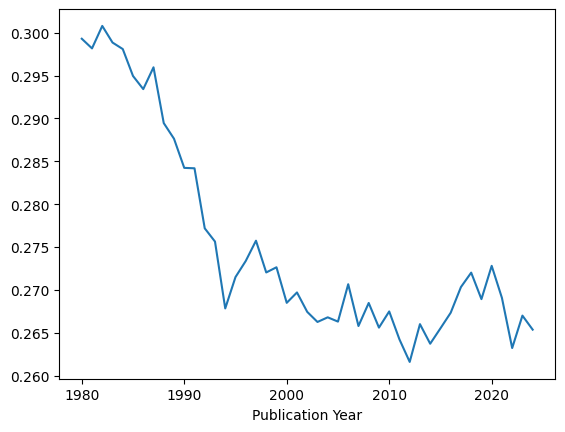

In [53]:
df_units_FMeasure['USA']['Clinical Medicine'].plot()

<Axes: xlabel='Publication Year'>

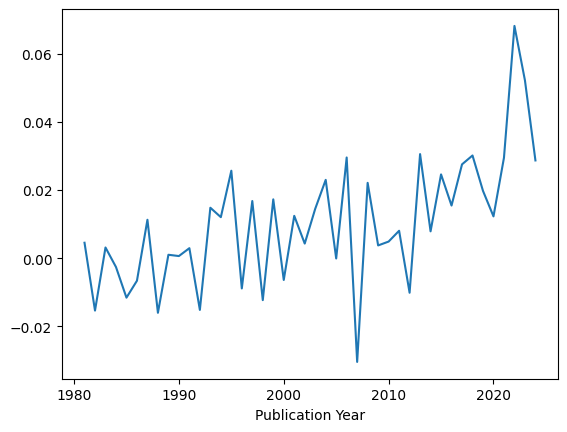

In [54]:
temp = df_units_AI['USA']['Clinical Medicine'] - df_units_AI['USA']['Clinical Medicine'].shift()
temp.plot()

<Axes: >

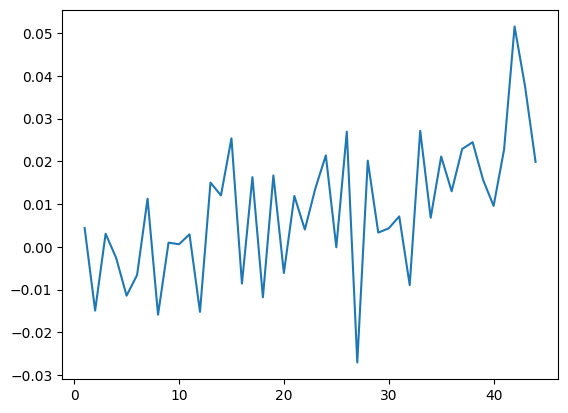

In [55]:
serieAI = pd.Series(df_units_AI['USA']['Clinical Medicine'].values.astype('float'))
serieAI.pct_change(periods=1).dropna().plot()

<Axes: >

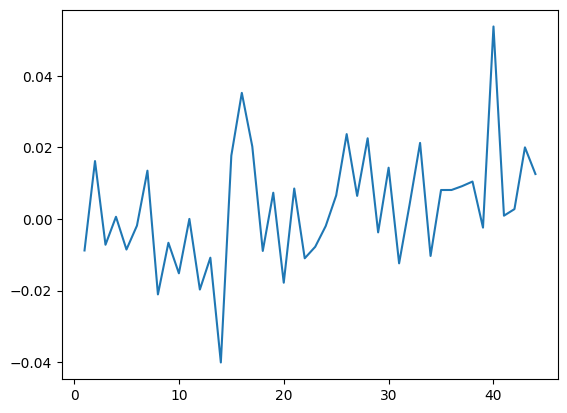

In [56]:
serieShare = pd.Series(df_units_share['USA']['Clinical Medicine'].values.astype('float'))
serieShare.pct_change(periods=1).dropna().plot()

# Correlations between indicators - Countries are the entities

In [57]:
#Remove 'Baseline for All Items' and 'Global Baseline'
units = list(units)
units.remove('Baseline for All Items')
units.remove('Global Baseline')
#units

In [58]:
listIndicators = ['Output','DShareC', 'CShareD', 'AI', 'RSI', 'FMeasure', 'Geometric Aggregtion']
listDfs = [df_units_production, df_units_share, df_units_wshare, df_units_AI, df_units_RSI, df_units_FMeasure,df_units_AMeasure, df_units_GMeasure, df_geometric_aggregation]

#Create dictionaries
dictCorrAreas = {}
dictCorrAreasDF = {}
dictCorrAreasDFAGMeans = {}
dictSpearmanCorrAreas = {}
dictSpearmanCorrAreasDF = {}
dictSpearmanCorrAreasDFAGMeans = {}


dictYearlyData = {}

#Create a dictionary in the dictionaries
for year in years:
  dictCorrAreas[year] = {}
  dictSpearmanCorrAreas[year] = {}
  dictCorrAreasDF[year] = pd.DataFrame(index = fileNames)
  dictCorrAreasDFAGMeans[year] = pd.DataFrame(index = fileNames)
  dictSpearmanCorrAreasDF[year] = pd.DataFrame(index = fileNames)
  dictSpearmanCorrAreasDFAGMeans[year] = pd.DataFrame(index = fileNames)
  dictYearlyData[year] = {}


  for area in fileNames:
    dfTemp = pd.DataFrame(index=units, columns = listIndicators)
    for unit in units:
      if not df_units_share[unit].empty and area in df_units_share[unit].columns and year in df_units_share[unit].index:
        #drop cero ouput countries
        if df_units[unit][area][year].astype('float') != 0:
          dfTemp.at[unit, 'Output'] = df_units[unit][area][year].astype('float')
          dfTemp.at[unit, 'DShareC'] = df_units_share[unit][area][year].astype('float')
          dfTemp.at[unit, 'CShareD'] = df_units_wshare[unit][area][year].astype('float')
          dfTemp.at[unit, 'AI'] = df_units_AI[unit][area][year].astype('float')
          dfTemp.at[unit, 'RSI'] = df_units_RSI[unit][area][year].astype('float')
          dfTemp.at[unit, 'FMeasure'] = df_units_FMeasure[unit][area][year].astype('float')
          dfTemp.at[unit, 'AMean'] = df_units_AMeasure[unit][area][year].astype('float')
          dfTemp.at[unit, 'GMean'] = df_units_GMeasure[unit][area][year].astype('float')
          dfTemp.at[unit, 'Geometric Aggregtion'] = df_geometric_aggregation[unit][area][year].astype('float')
    dfTemp = dfTemp.dropna(how='all')
    dfTemp = dfTemp.astype('float')
    ## CORRELATION COEFFICIENTS
    dictCorrAreas[year][area] = dfTemp.corr(method='pearson')
    dictSpearmanCorrAreas[year][area] = dfTemp.corr(method='spearman')
    ## TESTS AND DATA



    #dictCorrAreasDF[year].at[area,'AI vs Output'] = dictCorrAreas[year][area].at['AI','Output']
    dictCorrAreasDF[year].at[area,'Output'] =  df_areas.at[year,area]
    dictCorrAreasDF[year].at[area,'AI vs DShareC'] = dictCorrAreas[year][area].at['AI', 'DShareC']
    dictCorrAreasDF[year].at[area,'AI vs CShareD'] = dictCorrAreas[year][area].at['AI','CShareD']
    #dictCorrAreasDF[year].at[area,'F-Measure vs Output'] = dictCorrAreas[year][area].at['FMeasure','Output']
    dictCorrAreasDF[year].at[area,'F-Measure vs DShareC'] = dictCorrAreas[year][area].at['FMeasure', 'DShareC']
    dictCorrAreasDF[year].at[area,'F-Measure vs CShareD'] = dictCorrAreas[year][area].at['FMeasure', 'CShareD']
    #dictCorrAreasDF[year].at[area,'Geometric Aggregtion vs Output'] = dictCorrAreas[year][area].at['Geometric Aggregtion','Output']
    dictCorrAreasDF[year].at[area,'Geometric Aggregtion vs DShareC'] = dictCorrAreas[year][area].at['Geometric Aggregtion', 'DShareC']
    dictCorrAreasDF[year].at[area,'Geometric Aggregtion vs CShareD'] = dictCorrAreas[year][area].at['Geometric Aggregtion', 'CShareD']
    dictCorrAreasDF[year].at[area,'AI vs RSI'] = dictCorrAreas[year][area].at['AI','RSI']
    dictCorrAreasDF[year].at[area,'AI vs F-Measure'] = dictCorrAreas[year][area].at['AI','FMeasure']
    dictCorrAreasDF[year].at[area,'CShareD vs Output'] = dictCorrAreas[year][area].at['CShareD','Output']
    dictCorrAreasDF[year].at[area,'DShareC vs CShareD'] = dictCorrAreas[year][area].at['DShareC','CShareD']

    #dictSpearmanCorrAreasDF[year].at[area,'AI vs Output'] = dictSpearmanCorrAreas[year][area].at['AI','Output']
    dictSpearmanCorrAreasDF[year].at[area,'Output'] =  df_areas.at[year,area]
    dictSpearmanCorrAreasDF[year].at[area,'AI vs DShareC'] = dictSpearmanCorrAreas[year][area].at['AI', 'DShareC']
    dictSpearmanCorrAreasDF[year].at[area,'AI vs CShareD'] = dictSpearmanCorrAreas[year][area].at['AI','CShareD']
    #dictSpearmanCorrAreasDF[year].at[area,'F-Measure vs Output'] = dictSpearmanCorrAreas[year][area].at['FMeasure','Output']
    dictSpearmanCorrAreasDF[year].at[area,'F-Measure vs DShareC'] = dictSpearmanCorrAreas[year][area].at['FMeasure', 'DShareC']
    dictSpearmanCorrAreasDF[year].at[area,'F-Measure vs CShareD'] = dictSpearmanCorrAreas[year][area].at['FMeasure', 'CShareD']
    #dictSpearmanCorrAreasDF[year].at[area,'Geometric Aggregtion vs Output'] = dictSpearmanCorrAreas[year][area].at['Geometric Aggregtion','Output']
    dictSpearmanCorrAreasDF[year].at[area,'Geometric Aggregtion vs DShareC'] = dictSpearmanCorrAreas[year][area].at['Geometric Aggregtion', 'DShareC']
    dictSpearmanCorrAreasDF[year].at[area,'Geometric Aggregtion vs CShareD'] = dictSpearmanCorrAreas[year][area].at['Geometric Aggregtion', 'CShareD']
    dictSpearmanCorrAreasDF[year].at[area,'AI vs RSI'] = dictSpearmanCorrAreas[year][area].at['AI','RSI']
    dictSpearmanCorrAreasDF[year].at[area,'AI vs F-Measure'] = dictSpearmanCorrAreas[year][area].at['AI','FMeasure']
    dictSpearmanCorrAreasDF[year].at[area,'CShareD vs Output'] = dictSpearmanCorrAreas[year][area].at['CShareD','Output']
    dictSpearmanCorrAreasDF[year].at[area,'DShareC vs CShareD'] = dictSpearmanCorrAreas[year][area].at['DShareC','CShareD']

    #dictCorrAreasDFAGMeans[year].at[area,'A-Measure vs Output'] = dictCorrAreas[year][area].at['AMeasure','Output']
    dictCorrAreasDFAGMeans[year].at[area,'AMean vs DShareC'] = dictCorrAreas[year][area].at['AMean', 'DShareC']
    dictCorrAreasDFAGMeans[year].at[area,'AMean vs CShareD'] = dictCorrAreas[year][area].at['AMean','CShareD']
    dictCorrAreasDFAGMeans[year].at[area,'AMean vs F-Measure'] = dictCorrAreas[year][area].at['AMean','FMeasure']
    #dictCorrAreasDFAGMeans[year].at[area,'G-Measure vs Output'] = dictCorrAreas[year][area].at['GMeasure','Output']
    dictCorrAreasDFAGMeans[year].at[area,'GMean vs DShareC'] = dictCorrAreas[year][area].at['GMean', 'DShareC']
    dictCorrAreasDFAGMeans[year].at[area,'GMean vs CShareD'] = dictCorrAreas[year][area].at['GMean', 'CShareD']
    dictCorrAreasDFAGMeans[year].at[area,'GMean vs F-Measure'] = dictCorrAreas[year][area].at['GMean','FMeasure']

    #dictSpearmanCorrAreasDFAGMeans[year].at[area,'A-Measure vs Output'] = dictSpearmanCorrAreas[year][area].at['AMeasure','Output']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'AMean vs DShareC'] = dictSpearmanCorrAreas[year][area].at['AMean', 'DShareC']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'AMean vs CShareD'] = dictSpearmanCorrAreas[year][area].at['AMean','CShareD']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'AMean vs F-Measure'] = dictSpearmanCorrAreas[year][area].at['AMean','FMeasure']
    #dictSpearmanCorrAreasDFAGMeans[year].at[area,'G-Measure vs Output'] = dictSpearmanCorrAreas[year][area].at['GMeasure','Output']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'GMean vs DShareC'] = dictSpearmanCorrAreas[year][area].at['GMean', 'DShareC']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'GMean vs CShareD'] = dictSpearmanCorrAreas[year][area].at['GMean', 'CShareD']
    dictSpearmanCorrAreasDFAGMeans[year].at[area,'GMean vs F-Measure'] = dictSpearmanCorrAreas[year][area].at['GMean','FMeasure']

    dictYearlyData[year][area] = dfTemp


In [59]:
import os
import numpy as np
from scipy.stats import shapiro
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


text= '''
  <!DOCTYPE html>
  <html>
  <body>

  <br>
  <br>
  <h1>ScatterPlots</h1>
  <br>
  <br>
  <ul>
  '''


dicTests = {}
average = 0
os.makedirs('scatterplots', exist_ok = True)
os.makedirs('figuras', exist_ok = True)

for year in years:
  if year != 2024:
    continue
  os.makedirs('scatterplots/'+str(year), exist_ok = True)
  textScatterplots = '''
  <!DOCTYPE html>
  <html>
  <body>

  <br>
  <br>
  <h1>ScatterPlots '''+str(year)+'''+</h1>
  <br>
  <br>

  '''

  dicTests[year] = pd.DataFrame(index = fileNames)
  for area in fileNames:
    df = dictYearlyData[year][area].sort_values('Output', ascending=False)
    ## Select a subset indicators
    df = df[['Output','DShareC', 'CShareD', 'AI', 'FMeasure', 'RSI']]
    # Add the table to the html
    textScatterplots = textScatterplots +'''<br> <br> <h1>'''+ str(year) + " - "+area +'''</h1> <br><br>'''

    cm = sns.light_palette("lightblue", as_cmap=True)
    s = df.style.background_gradient(cmap=cm)
    textScatterplots = textScatterplots + s.to_html()
    textScatterplots = textScatterplots + '''<br><br>'''
    ## Create a pairplot with plotly
    fig = px.scatter_matrix(df,
                            dimensions=df.columns,
                            symbol=df.index,
                            title=str(year) + " - "+area)
    fig.update_traces(diagonal_visible=False)
    areaS = area.replace('/', '')
    figName = 'scatterplots/'+str(year)+'/'+str(year)+'_'+areaS
    figNamehtml = figName+'.html'
    #html
    fig.write_html(figNamehtml,
                   full_html=False,
                   include_plotlyjs='cdn')

    textScatterplots = textScatterplots + '''<a href="'''+figNamehtml.replace('scatterplots/', '')+'''">Plotly - '''+area+'''</a>'''

    textScatterplots = textScatterplots + '''
    <br><br>
    '''
    # Set a global font scale
    sns.set_theme(font_scale=1.6)
    #Create a pairplot with seaborn
    scatter_plot  = sns.pairplot(df)
    scatter_fig = scatter_plot.fig
    scatter_fig.savefig(figName+'.png')
    textScatterplots = textScatterplots + '''
    <img src="'''+figName.replace('scatterplots/', '')+'''.png" alt="'''+str(year) + ''' - '''+area+'''">
    <br><br>'''
    #Intent closing the figure
    plt.close()

    dicTests[year].at[area,'Number of Countries'] = len(df)
    for indicator in df.columns:
      stat, p = shapiro(df[indicator])
      if p > 0.05:
        dicTests[year].at[area, indicator +'-Shapiro' ] = 1
      else:
        dicTests[year].at[area, indicator +'-Shapiro' ] = 0
  ave =  dicTests[year]['Number of Countries'].mean()
  print(year, ' - ' , ave)
  average += ave
  #close html and save it
  textScatterplots = textScatterplots + '''  </body></html>'''

  file = open("scatterplots/scatterPlots_"+str(year)+".html","w")
  file.write(textScatterplots)
  file.close()
  text = text + '''<li><a href="'''+"scatterplots/scatterPlots_"+str(year)+".html"+'''">'''+str(year)+'''</a></li>'''





text = text + '''</ul> </body></html>'''
file = open("scatterplots.html","w")
file.write(text)
file.close()

average = average / len(years)
print('Average', average)


2024.0  -  180.13636363636363
Average 4.003030303030303


In [60]:
import plotly.express as px

fig = px.scatter_matrix(dfTemp,
    dimensions=dfTemp.columns,
                        symbol=dfTemp.index,
    title="Scatter matrix") # remove underscore
fig.update_traces(diagonal_visible=False)


fig.show()

In [61]:
import plotly.express as px

fig = px.scatter_matrix(dfTemp,
    dimensions=dfTemp.columns,
                        symbol=dfTemp.index,
    title="Scatter matrix") # remove underscore
fig.update_traces(diagonal_visible=False)

fig.update_layout(
    xaxis=dict(type='log'),
    yaxis=dict(type='log'),)


In [62]:
dfTemp.head()

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
AFGHANISTAN,3.0,0.006329,0.000161,0.794949,-0.114238,0.000313,0.092225,0.003245,0.001008
ALBANIA,4.0,0.008889,0.000214,1.116461,0.055026,0.000418,0.108910,0.004551,0.001379
ALGERIA,26.0,0.004070,0.001391,0.511216,-0.323437,0.002074,0.101095,0.002731,0.002380
ARGENTINA,249.0,0.023638,0.013323,2.968945,0.496088,0.017041,0.269169,0.018480,0.017746
ARMENIA,58.0,0.051282,0.003103,6.441122,0.731223,0.005852,0.282162,0.027193,0.012615


In [63]:
# x and y given as array_like objects
import plotly.express as px
fig = px.scatter(x=dfTemp['CShareD'], y=dfTemp['DShareC'])
fig.update_layout(
    xaxis=dict(type='log'),
    yaxis=dict(type='log'),)
fig.show()

# Create and html report

In [156]:
text = '''<h1>Manuscript figures and tables - Global Context</h1>

Pearson correlations in the year 2024 with countries as entities
'''

In [157]:
import seaborn as sns

def style_negative(v, props=''):
    return props if v < 0 else None

df = dictCorrAreasDF[2024].sort_values('F-Measure vs DShareC', ascending=False)
pd.set_option("styler.format.precision", 4)
cm = sns.light_palette("lightblue", as_cmap=True)

if(len(df) > 50):
  s = df.head(50).style.background_gradient(cmap=cm, vmin=0, vmax=1)
else:
  s = df.style.background_gradient(cmap=cm, vmin=0, vmax=1)
s.applymap(style_negative, props='color:red;')
text = text + s.to_html()

df.to_csv('pearson_correlation_AI_FMeasure.csv')

/tmp/ipykernel_10736/3476100339.py:14: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



In [158]:
import seaborn as sns

df = dictCorrAreasDFAGMeans[2024]
pd.set_option("styler.format.precision", 4)
cm = sns.light_palette("lightblue", as_cmap=True)

if(len(df) > 50):
  s = df.head(50).style.background_gradient(cmap=cm, vmin=0, vmax=1)
else:
  s = df.style.background_gradient(cmap=cm, vmin=0, vmax=1)
s.applymap(style_negative, props='color:red;')
text = text + s.to_html()

/tmp/ipykernel_10736/341907909.py:11: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



In [159]:
text = text + '''
<h1>Spearman correlations in the year 2024 with countries as entities</h1>
'''

In [160]:
import seaborn as sns

df = dictSpearmanCorrAreasDF[2024].sort_values('F-Measure vs DShareC', ascending=False)
pd.set_option("styler.format.precision", 4)
cm = sns.light_palette("lightblue", as_cmap=True)

#if(len(df) > 100):
#  s = df.head(100).style.background_gradient(cmap=cm)
#else:
#  s = df.style.background_gradient(cmap=cm)

s = df.style.background_gradient(cmap=cm, vmin=0, vmax=1)
s.applymap(style_negative, props='color:red;')
text = text + s.to_html()

df.to_csv('Spearman_correlation_AI_FMeasure.csv')

/tmp/ipykernel_10736/3593759221.py:13: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



In [161]:
import seaborn as sns

df = dictSpearmanCorrAreasDFAGMeans[2024]
pd.set_option("styler.format.precision", 4)
cm = sns.light_palette("lightblue", as_cmap=True)

#if(len(df) > 100):
#  s = df.head(100).style.background_gradient(cmap=cm)
#else:
#  s = df.style.background_gradient(cmap=cm)

s = df.style.background_gradient(cmap=cm, vmin=0, vmax=1)
s.applymap(style_negative, props='color:red;')
text = text + s.to_html()

/tmp/ipykernel_10736/2210391947.py:13: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



### Charts

In [162]:
dictYearlyData[year][area]

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
AFGHANISTAN,3.0,0.006329,0.000161,0.794949,-0.114238,0.000313,0.092225,0.003245,0.001008
ALBANIA,4.0,0.008889,0.000214,1.116461,0.055026,0.000418,0.108910,0.004551,0.001379
ALGERIA,26.0,0.004070,0.001391,0.511216,-0.323437,0.002074,0.101095,0.002731,0.002380
ARGENTINA,249.0,0.023638,0.013323,2.968945,0.496088,0.017041,0.269169,0.018480,0.017746
ARMENIA,58.0,0.051282,0.003103,6.441122,0.731223,0.005852,0.282162,0.027193,0.012615
...,...,...,...,...,...,...,...,...,...
VENEZUELA,7.0,0.012704,0.000375,1.595668,0.229485,0.000728,0.132066,0.006539,0.002181
VIETNAM,34.0,0.003370,0.001819,0.423237,-0.405247,0.002363,0.100700,0.002594,0.002476
WALES,190.0,0.029827,0.010166,3.746367,0.578625,0.015164,0.273532,0.019997,0.017413
YEMEN,1.0,0.001007,0.000054,0.126487,-0.775431,0.000102,0.039049,0.000530,0.000232


In [163]:
import plotly.express as px
import plotly.graph_objs as go

# Tnaks to user171780 in https://stackoverflow.com/questions/61494278/plotly-how-to-make-a-figure-with-multiple-lines-and-shaded-area-for-standard-de
def line(error_y_mode=None, **kwargs):
    """Extension of `plotly.express.line` to use error bands."""
    ERROR_MODES = {'bar','band','bars','bands',None}
    if error_y_mode not in ERROR_MODES:
        raise ValueError(f"'error_y_mode' must be one of {ERROR_MODES}, received {repr(error_y_mode)}.")
    if error_y_mode in {'bar','bars',None}:
        fig = px.line(**kwargs)
    elif error_y_mode in {'band','bands'}:
        if 'error_y' not in kwargs:
            raise ValueError(f"If you provide argument 'error_y_mode' you must also provide 'error_y'.")
        figure_with_error_bars = px.line(**kwargs)
        fig = px.line(**{arg: val for arg,val in kwargs.items() if arg != 'error_y'})
        for data in figure_with_error_bars.data:
            x = list(data['x'])
            y_upper = list(data['y'] + data['error_y']['array'])
            y_lower = list(data['y'] - data['error_y']['array'] if data['error_y']['arrayminus'] is None else data['y'] - data['error_y']['arrayminus'])
            color = f"rgba({tuple(int(data['line']['color'].lstrip('#')[i:i+2], 16) for i in (0, 2, 4))},.3)".replace('((','(').replace('),',',').replace(' ','')
            fig.add_trace(
                go.Scatter(
                    x = x+x[::-1],
                    y = y_upper+y_lower[::-1],
                    fill = 'toself',
                    fillcolor = color,
                    line = dict(
                        color = 'rgba(255,255,255,0)'
                    ),
                    hoverinfo = "skip",
                    showlegend = False,
                    legendgroup = data['legendgroup'],
                    xaxis = data['xaxis'],
                    yaxis = data['yaxis'],
                )
            )
        # Reorder data as said here: https://stackoverflow.com/a/66854398/8849755
        reordered_data = []
        fig.update_layout(hovermode="x")
        for i in range(int(len(fig.data)/2)):
            reordered_data.append(fig.data[i+int(len(fig.data)/2)])
            reordered_data.append(fig.data[i])
        fig.data = tuple(reordered_data)
    return fig

# This function receives a dataframe containing de correlations
def makeMeanStdSeries(df, cols):
  dfResult = pd.DataFrame(columns=['Name', 'Year', 'Mean', 'Std'])
  for year in years:
    for col in cols:
      dft = df[year][[col]]
      dftDesception = dft.describe()
      dfResult.loc[len(dfResult.index)] = [col, year, dftDesception.at['mean', col], dftDesception.at['std', col]]
  return dfResult

def makeSeries(df, col):
  dfResult = pd.DataFrame(columns=['Domain Area', 'Year', col])
  for year in years:
    dft = df[year][[col]]
    for area in areas:
      dfResult.loc[len(dfResult.index)] = [area, year, dft.at[area, col]]#Agregar un renglon
  return dfResult

def makeAreaSeries(df, col):

  dfT = df[2024][[col]]
  minV = dfT.min().values[0]
  areaMin = dfT[dfT[col] == minV].index[0]
  maxV = dfT.max().values[0]
  areaMax = dfT[dfT[col] == maxV].index[0]

  dfResult = pd.DataFrame(columns=['Domain', 'Year', col])
  for year in years:
    dfAreaMax = df[year][[col]].loc[[areaMax]]
    dfAreaMax['Year'] = year
    dfAreaMax['Domain'] = areaMax
    dfResult = pd.concat([dfResult, dfAreaMax])
    dfAreaMin = df[year][[col]].loc[[areaMin]]
    dfAreaMin['Year'] = year
    dfAreaMin['Domain'] = areaMin
    dfResult = pd.concat([dfResult, dfAreaMin])
  return dfResult


In [164]:
import plotly.graph_objects as go

# Get the dataframe for the current year and sort it by 'Output'
df_plot = dictSpearmanCorrAreasDF[year].sort_values('F-Measure vs DShareC', ascending=False)

# Create a new figure
fig = go.Figure()

# Add traces for 'F-Measure vs DShareC'
fig.add_trace(go.Bar(
    x=df_plot.index, # Areas on the x-axis
    y=df_plot['F-Measure vs DShareC'],
    name='F-Measure vs DShareC'
))

# Add traces for 'F-Measure vs CShareD'
fig.add_trace(go.Bar(
    x=df_plot.index, # Areas on the x-axis
    y=df_plot['F-Measure vs CShareD'],
    name='F-Measure vs CShareD'
))

# Update layout for better readability
fig.update_layout(
    title=f'F-Measure Correlations per Area (Year {year}) - Ordered by Output',
    xaxis_title='Domain Area',
    yaxis_title='Spearman Correlation Value',
    barmode='group', # Group bars for each area
    height=600
)

fig.show()


figName = 'figuras/Spearman_correlation_DomainAreas_FMeasureDShareC_CShareD'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [165]:
df = makeSeries(dictCorrAreasDF, 'F-Measure vs DShareC')
df = df[df['Year'].isin([1980, 1990, 2000, 2010, 2020, 2024])]
fig = px.box(df, y="F-Measure vs DShareC", x="Year", color="Year",  points="all", title = 'Pearson Correlation',
          hover_data=df.columns)
fig.update_layout(
    font=dict(
        size=18,
    )
)
fig.show()

figName = 'figuras/pearson_correlation_longitudinal_fmeasure_nshare'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=True,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [166]:
df = makeSeries(dictSpearmanCorrAreasDF, 'F-Measure vs DShareC')
df = df[df['Year'].isin([1980, 1990, 2000, 2010, 2020, 2024])]
fig = px.box(df, y="F-Measure vs DShareC", x="Year", color="Year",  points="all", title = 'Spearman Correlation',
          hover_data=df.columns)
fig.update_layout(
    font=dict(
        size=18,
    ))
fig.show()

figName = 'figuras/spearman_correlation_longitudinal_fmeasure_nshare'
figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [167]:
df = makeSeries(dictCorrAreasDF, 'F-Measure vs CShareD')
df = df[df['Year'].isin([1980, 1990, 2000, 2010, 2020, 2024])]
fig = px.box(df, y="F-Measure vs CShareD", x="Year", color="Year",  points="all", title = 'Pearson Correlation',
          hover_data=df.columns)
fig.update_layout(
    font=dict(
        size=18,
    ))
fig.show()

figName = 'figuras/pearson_correlation_longitudinal_fmeasure_wshare'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [168]:
df =makeSeries(dictSpearmanCorrAreasDF, 'F-Measure vs DShareC')
df=df[df['Year']==2024]
df = df[['Domain Area', 'F-Measure vs DShareC']]
df = df.sort_values(by='F-Measure vs DShareC', ascending=False)
df

,Domain Area,F-Measure vs DShareC
978,Materials Science,0.739605
989,Space Science,0.712947
985,Physics,0.651072
970,Chemistry,0.649901
972,Computer Science,0.607523
974,Engineering,0.591717
969,Biology & Biochemistry,0.504697
973,Economics & Business,0.503932
979,Mathematics,0.452448
983,Neuroscience & Behavior,0.446459


In [169]:
df.describe()

,F-Measure vs DShareC
count,22.000000
mean,0.247971
std,0.360691
min,-0.327751
25%,-0.062423
50%,0.326634
75%,0.569962
max,0.739605


In [170]:
df = makeSeries(dictSpearmanCorrAreasDF, 'F-Measure vs CShareD')
df = df[df['Year'].isin([1980, 1990, 2000, 2010, 2020, 2024])]
fig = px.box(df, y="F-Measure vs CShareD", x="Year", color="Year",  points="all", title = 'Spearman Correlation',
          hover_data=df.columns)
fig.update_layout(
    font=dict(
        size=18,
    ))
fig.show()

figName = 'figuras/spearman_correlation_longitudinal_fmeasure_wshare'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')

text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [171]:
dfT = makeMeanStdSeries(dictCorrAreasDF, ['F-Measure vs DShareC', 'F-Measure vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Pearson Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/pearson_correlation_evolution_fmeasure'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [172]:
dfT = makeMeanStdSeries(dictSpearmanCorrAreasDF, ['F-Measure vs DShareC', 'F-Measure vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Spearman Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/spearman_correlation_evolution_fmeasure'


figNamehtml = figName+'.html'
#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [173]:
dfT = makeMeanStdSeries(dictCorrAreasDF, ['Geometric Aggregtion vs DShareC', 'Geometric Aggregtion vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Pearson Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/pearson_correlation_evolution_Geometric_aggregtion'


figNamehtml = figName+'.html'
#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [174]:
dfT = makeMeanStdSeries(dictCorrAreasDF, ['AI vs DShareC', 'AI vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'band', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Pearson Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/pearson_correlation_evolution_AI'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [175]:
dfT = makeMeanStdSeries(dictSpearmanCorrAreasDF, ['AI vs DShareC', 'AI vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'band', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Spearman Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/spearman_correlation_evolution_AI'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [176]:
df = makeSeries(dictCorrAreasDF, 'AI vs CShareD')
df = df[df['Year'].isin([1980, 1990, 2000, 2010, 2020, 2024])]
fig = px.box(df, y="AI vs CShareD", x="Year", color="Year",  points="all", title = 'Pearson Correlation',
          hover_data=df.columns)
fig.show()

figName = 'figuras/pearson_correlation_longitudinal_AI_wshare'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [177]:

dfT = makeMeanStdSeries(dictCorrAreasDFAGMeans, ['AMean vs DShareC', 'AMean vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Pearson Correlation',
        markers = '.',
    )
fig.show()

figName = 'figuras/pearson_correlation_evolution_A-Measure'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [178]:

dfT = makeMeanStdSeries(dictSpearmanCorrAreasDFAGMeans, ['AMean vs DShareC', 'AMean vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Spearman Correlation',
        markers = '.',
    )
fig.show()


figName = 'figuras/spearman_correlation_evolution_A-Measure'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [179]:

dfT = makeMeanStdSeries(dictCorrAreasDFAGMeans, ['GMean vs DShareC', 'GMean vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Pearson Correlation',
        markers = '.',
    )
fig.show()


figName = 'figuras/pearson_correlation_evolution_G-Measure'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [180]:
dfT = makeMeanStdSeries(dictSpearmanCorrAreasDFAGMeans, ['GMean vs DShareC', 'GMean vs CShareD'])

fig = line(
        data_frame = dfT,
        x = 'Year',
        y = 'Mean',
        error_y = 'Std',
        error_y_mode = 'bands', # Here you say `band` or `bar`.
        color = 'Name',
        title = 'Spearman Correlation',
        markers = '.',
    )
fig.show()


figName = 'figuras/spearman_correlation_evolution_G-Measure'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [181]:
import plotly.graph_objects as go

# Get the dataframe for the current year and sort it by 'Output'
df_plot = dictCorrAreasDF[year].sort_values('Output', ascending=False)

# Create a new figure
fig = go.Figure()

# Add traces for 'F-Measure vs DShareC'
fig.add_trace(go.Bar(
    x=df_plot.index, # Areas on the x-axis
    y=df_plot['F-Measure vs DShareC'],
    name='F-Measure vs DShareC'
))

# Add traces for 'F-Measure vs CShareD'
fig.add_trace(go.Bar(
    x=df_plot.index, # Areas on the x-axis
    y=df_plot['F-Measure vs CShareD'],
    name='F-Measure vs CShareD'
))

# Update layout for better readability
fig.update_layout(
    title=f'F-Measure Correlations per Area (Year {year}) - Ordered by Output',
    xaxis_title='Domain Area',
    yaxis_title='Correlation Value',
    barmode='group', # Group bars for each area
    height=600
)

fig.show()


figName = 'figuras/pearson_correlation_FMeasureDShareC'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [182]:
import plotly.express as px

col = 'F-Measure vs DShareC'
df = makeAreaSeries(dictCorrAreasDF, col)

fig = px.line(df, x="Year", y=col, color='Domain', title = 'Pearson Correlation', markers = '.')
fig.show()


figName = 'figuras/pearson_correlation_evolution_FMeasureDShareC2Areas'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''


/tmp/ipykernel_10736/3487044262.py:78: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [183]:
import plotly.express as px

col = 'F-Measure vs DShareC'
df = makeAreaSeries(dictSpearmanCorrAreasDF, col)

fig = px.line(df, x="Year", y=col, color='Domain', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/spearman_correlation_best_worst_fmeasure_nshare'

figNamehtml = figName+'.html'
#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

/tmp/ipykernel_10736/3487044262.py:78: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [184]:
col = 'AI vs CShareD'
df = makeAreaSeries(dictSpearmanCorrAreasDF, col)

fig = px.line(df, x="Year", y=col, color='Domain', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/spearman_correlation_best_worst_ai_wshare'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

/tmp/ipykernel_10736/3487044262.py:78: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [185]:
import plotly.express as px

df = makeSeries(dictCorrAreasDF, 'F-Measure vs DShareC')
fig = px.line(df, x="Year", y="F-Measure vs DShareC", color='Domain Area',  title = 'Pearson Correlation', markers = '.')
fig.show()

figName = 'figuras/pearson_correlation_fmeasure_DShareC_alldomains'


figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [186]:
import plotly.express as px

df = makeSeries(dictCorrAreasDF, 'F-Measure vs CShareD')
fig = px.line(df, x="Year", y="F-Measure vs CShareD", color='Domain Area', title = 'Pearson Correlation', markers = '.')
fig.show()

figName = 'figuras/pearson_correlation_fmeasure_CShareD_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [187]:
import plotly.express as px

df = makeSeries(dictCorrAreasDF, 'AI vs DShareC')
fig = px.line(df, x="Year", y="AI vs DShareC", color='Domain Area',  title = 'Pearson Correlation', markers = '.')
fig.show()


figName = 'figuras/pearson_correlation_AI_DShareC_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [188]:
import plotly.express as px

df = makeSeries(dictCorrAreasDF, 'AI vs CShareD')
fig = px.line(df, x="Year", y="AI vs CShareD", color='Domain Area',  title = 'Pearson Correlation', markers = '.')
fig.show()

figName = 'figuras/pearson_correlation_AI_CShareD_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [189]:
import plotly.express as px

df = makeSeries(dictSpearmanCorrAreasDF, 'F-Measure vs DShareC')
fig = px.line(df, x="Year", y="F-Measure vs DShareC", color='Domain Area', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/Spearman_correlation_fmeasure_DShareC_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [190]:
import plotly.express as px

df = makeSeries(dictSpearmanCorrAreasDF, 'F-Measure vs CShareD')
fig = px.line(df, x="Year", y="F-Measure vs CShareD", color='Domain Area', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/Spearman_correlation_fmeasure_CShareD_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [191]:
import plotly.express as px

df = makeSeries(dictSpearmanCorrAreasDF, 'AI vs DShareC')
fig = px.line(df, x="Year", y="AI vs DShareC", color='Domain Area', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/Spearman_correlation_AI_DShareC_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

In [192]:
import plotly.express as px

df = makeSeries(dictSpearmanCorrAreasDF, 'AI vs CShareD')
fig = px.line(df, x="Year", y="AI vs CShareD", color='Domain Area', title = 'Spearman Correlation', markers = '.')
fig.show()

figName = 'figuras/Spearman_correlation_AI_CShareD_alldomains'

figNamehtml = figName+'.html'

#html
fig.write_html(figNamehtml,
              full_html=False,
              include_plotlyjs='cdn')
text = text + '''<iframe src="'''+figNamehtml+'''" width="100%" height="100%"></iframe>'''

# Tables

In [101]:
print(year)
dictCorrAreas[year][area].style.format(precision=4)

2024.0


,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.0000,0.0339,1.0000,0.0339,0.3037,0.6715,0.7698,0.7407,0.8487
DShareC,0.0339,1.0000,0.0339,1.0000,0.3983,0.1232,0.4876,0.6966,0.2213
CShareD,1.0000,0.0339,1.0000,0.0339,0.3037,0.6715,0.7698,0.7407,0.8487
AI,0.0339,1.0000,0.0339,1.0000,0.3983,0.1232,0.4876,0.6966,0.2213
RSI,0.3037,0.3983,0.3037,0.3983,1.0000,0.5937,0.7359,0.4858,0.5865
FMeasure,0.6715,0.1232,0.6715,0.1232,0.5937,1.0000,0.8303,0.5649,0.9467
Geometric Aggregtion,0.7698,0.4876,0.7698,0.4876,0.7359,0.8303,1.0000,0.8804,0.9240
AMean,0.7407,0.6966,0.7407,0.6966,0.4858,0.5649,0.8804,1.0000,0.7581
GMean,0.8487,0.2213,0.8487,0.2213,0.5865,0.9467,0.9240,0.7581,1.0000


In [102]:
dictCorrAreasDF[2024].style.format(precision=4)

,Output,AI vs DShareC,AI vs CShareD,F-Measure vs DShareC,F-Measure vs CShareD,Geometric Aggregtion vs DShareC,Geometric Aggregtion vs CShareD,AI vs RSI,AI vs F-Measure,CShareD vs Output,DShareC vs CShareD
Agricultural Sciences,78434.0000,1.0000,-0.0516,-0.0763,0.6877,0.6142,0.6084,0.8250,-0.0763,1.0000,-0.0516
Biology & Biochemistry,89531.0000,1.0000,0.1395,0.2767,0.7573,0.6171,0.7594,0.9596,0.2767,1.0000,0.1395
Chemistry,235686.0000,1.0000,0.1776,0.3248,0.8705,0.8376,0.5850,0.9590,0.3248,1.0000,0.1776
Clinical Medicine,413753.0000,1.0000,-0.0138,-0.0036,0.9416,0.8024,0.4730,0.8854,-0.0036,1.0000,-0.0138
Computer Science,75009.0000,1.0000,0.1433,0.3555,0.7200,0.6995,0.6843,0.9116,0.3555,1.0000,0.1433
Economics & Business,45936.0000,1.0000,0.0902,0.2668,0.7091,0.5899,0.7641,0.8842,0.2668,1.0000,0.0902
Engineering,319145.0000,1.0000,0.1769,0.2586,0.9333,0.8510,0.5488,0.9561,0.2586,1.0000,0.1769
Environment/Ecology,99151.0000,1.0000,-0.1197,-0.2360,0.7334,0.7709,0.4010,0.7366,-0.2360,1.0000,-0.1197
Geosciences,74557.0000,1.0000,-0.0414,-0.1000,0.7172,0.6221,0.6277,0.8345,-0.1000,1.0000,-0.0414
Immunology,35184.0000,1.0000,-0.0967,-0.1727,0.6597,0.7523,0.4197,0.5935,-0.1727,1.0000,-0.0967


In [103]:
dictCorrAreasDF[2022].style.format(precision=4)

,Output,AI vs DShareC,AI vs CShareD,F-Measure vs DShareC,F-Measure vs CShareD,Geometric Aggregtion vs DShareC,Geometric Aggregtion vs CShareD,AI vs RSI,AI vs F-Measure,CShareD vs Output,DShareC vs CShareD
Agricultural Sciences,72435.0000,1.0000,-0.0600,-0.0412,0.6933,0.5735,0.6541,0.9383,-0.0412,1.0000,-0.0600
Biology & Biochemistry,93071.0000,1.0000,0.1221,0.2265,0.7888,0.6167,0.7484,0.9218,0.2265,1.0000,0.1221
Chemistry,231910.0000,1.0000,0.1927,0.3330,0.8829,0.8474,0.5826,0.9600,0.3330,1.0000,0.1927
Clinical Medicine,422755.0000,1.0000,0.0221,0.0401,0.9512,0.8040,0.5173,0.9294,0.0401,1.0000,0.0221
Computer Science,74909.0000,1.0000,0.1541,0.3500,0.7384,0.7081,0.6916,0.9216,0.3500,1.0000,0.1541
Economics & Business,42901.0000,1.0000,0.1035,0.2509,0.7445,0.5827,0.7732,0.8778,0.2509,1.0000,0.1035
Engineering,286055.0000,1.0000,0.1964,0.3026,0.9217,0.8577,0.5646,0.9587,0.3026,1.0000,0.1964
Environment/Ecology,127871.0000,1.0000,-0.1740,-0.3012,0.7912,0.6665,0.5061,0.9055,-0.3012,1.0000,-0.1740
Geosciences,75258.0000,1.0000,-0.0352,-0.0851,0.7504,0.6094,0.6487,0.8338,-0.0851,1.0000,-0.0352
Immunology,39083.0000,1.0000,-0.1303,-0.2259,0.6915,0.7220,0.4915,0.7878,-0.2259,1.0000,-0.1303


In [104]:
dictCorrAreasDF[year].describe().style.format(precision=4)

,Output,AI vs DShareC,AI vs CShareD,F-Measure vs DShareC,F-Measure vs CShareD,Geometric Aggregtion vs DShareC,Geometric Aggregtion vs CShareD,AI vs RSI,AI vs F-Measure,CShareD vs Output,DShareC vs CShareD
count,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000
mean,106704.5000,1.0000,0.0361,0.0928,0.7322,0.6465,0.6403,0.8316,0.0928,1.0000,0.0361
std,100361.3202,0.0000,0.1276,0.2208,0.1387,0.1717,0.1356,0.1310,0.2208,0.0000,0.1276
min,4025.0000,1.0000,-0.1530,-0.2360,0.2678,0.0986,0.4010,0.3983,-0.2360,1.0000,-0.1530
25%,50150.0000,1.0000,-0.0495,-0.0941,0.6780,0.5956,0.5525,0.7895,-0.0941,1.0000,-0.0495
50%,74783.0000,1.0000,0.0227,0.1014,0.7253,0.6622,0.6453,0.8548,0.1014,1.0000,0.0227
75%,114913.0000,1.0000,0.1352,0.2647,0.7862,0.7615,0.7556,0.9113,0.2647,1.0000,0.1352
max,413753.0000,1.0000,0.3075,0.5254,0.9416,0.8510,0.8696,0.9596,0.5254,1.0000,0.3075


In [105]:
dictCorrAreasDF[1980].style.format(precision=4)

,Output,AI vs DShareC,AI vs CShareD,F-Measure vs DShareC,F-Measure vs CShareD,Geometric Aggregtion vs DShareC,Geometric Aggregtion vs CShareD,AI vs RSI,AI vs F-Measure,CShareD vs Output,DShareC vs CShareD
Agricultural Sciences,10508.0000,1.0000,-0.1025,-0.1388,0.6415,0.8685,0.2650,0.6685,-0.1388,1.0000,-0.1025
Biology & Biochemistry,28209.0000,1.0000,-0.0225,-0.0233,0.8218,0.7371,0.5048,0.7468,-0.0233,1.0000,-0.0225
Chemistry,38250.0000,1.0000,-0.0145,0.0269,0.8551,0.8216,0.4317,0.7785,0.0269,1.0000,-0.0145
Clinical Medicine,73867.0000,1.0000,-0.0337,-0.0391,0.9357,0.8394,0.4195,0.9201,-0.0391,1.0000,-0.0337
Computer Science,3685.0000,1.0000,-0.0392,-0.1228,0.6086,0.4569,0.7744,0.6403,-0.1228,1.0000,-0.0392
Economics & Business,5613.0000,1.0000,-0.0079,-0.0006,0.6848,0.5614,0.7341,0.7350,-0.0006,1.0000,-0.0079
Engineering,17349.0000,1.0000,-0.0572,-0.0913,0.7760,0.6613,0.6062,0.8681,-0.0913,1.0000,-0.0572
Environment/Ecology,5173.0000,1.0000,-0.0962,-0.2437,0.6101,0.7210,0.5376,0.7367,-0.2437,1.0000,-0.0962
Geosciences,8830.0000,1.0000,-0.0638,-0.1049,0.6771,0.7855,0.4423,0.6489,-0.1049,1.0000,-0.0638
Immunology,5686.0000,1.0000,-0.0631,-0.0944,0.5564,0.6469,0.6011,0.7209,-0.0944,1.0000,-0.0631


In [106]:
dictSpearmanCorrAreasDF[2024].style.format(precision=3)
dictSpearmanCorrAreasDF[2024].to_csv('spearman_correlation_2024.csv')

In [107]:
dictSpearmanCorrAreasDF[year].describe().style.format(precision=4)

,Output,AI vs DShareC,AI vs CShareD,F-Measure vs DShareC,F-Measure vs CShareD,Geometric Aggregtion vs DShareC,Geometric Aggregtion vs CShareD,AI vs RSI,AI vs F-Measure,CShareD vs Output,DShareC vs CShareD
count,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000
mean,106704.5000,1.0000,0.2076,0.2480,0.9945,0.7966,0.6336,1.0000,0.2480,1.0000,0.2076
std,100361.3202,0.0000,0.3742,0.3607,0.0178,0.1592,0.2222,0.0000,0.3607,0.0000,0.3742
min,4025.0000,1.0000,-0.3696,-0.3278,0.9161,0.2191,0.2580,1.0000,-0.3278,1.0000,-0.3696
25%,50150.0000,1.0000,-0.0804,-0.0624,0.9981,0.7511,0.4506,1.0000,-0.0624,1.0000,-0.0804
50%,74783.0000,1.0000,0.2946,0.3266,0.9990,0.8358,0.7391,1.0000,0.3266,1.0000,0.2946
75%,114913.0000,1.0000,0.5552,0.5700,0.9996,0.8881,0.8144,1.0000,0.5700,1.0000,0.5552
max,413753.0000,1.0000,0.7253,0.7396,1.0000,0.9499,0.8819,1.0000,0.7396,1.0000,0.7253


In [108]:
dictCorrAreasDFAGMeans[year].style.format(precision=4)

,AMean vs DShareC,AMean vs CShareD,AMean vs F-Measure,GMean vs DShareC,GMean vs CShareD,GMean vs F-Measure
Agricultural Sciences,0.7090,0.6677,0.4288,0.0120,0.8374,0.9464
Biology & Biochemistry,0.5170,0.9197,0.7643,0.2936,0.8690,0.9716
Chemistry,0.8329,0.6925,0.7276,0.4484,0.8591,0.9805
Clinical Medicine,0.9729,0.2178,0.2143,0.0136,0.8711,0.9693
Computer Science,0.5324,0.9141,0.7615,0.4086,0.8688,0.9520
Economics & Business,0.4748,0.9193,0.7320,0.3207,0.8518,0.9609
Engineering,0.8692,0.6404,0.6707,0.3834,0.8921,0.9783
Environment/Ecology,0.9464,0.2073,0.0059,-0.1774,0.8334,0.9540
Geosciences,0.7297,0.6529,0.4150,-0.0366,0.8725,0.9537
Immunology,0.9382,0.2537,0.0615,-0.0051,0.8191,0.8962


In [109]:
dictCorrAreasDFAGMeans[year].describe().style.format(precision=4)

,AMean vs DShareC,AMean vs CShareD,AMean vs F-Measure,GMean vs DShareC,GMean vs CShareD,GMean vs F-Measure
count,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000
mean,0.6817,0.6797,0.5081,0.1669,0.8543,0.9463
std,0.2286,0.2619,0.2614,0.2132,0.0303,0.0559
min,0.0069,0.2010,0.0059,-0.1774,0.7947,0.7139
25%,0.5421,0.6030,0.3448,-0.0008,0.8344,0.9475
50%,0.7028,0.7386,0.5828,0.1707,0.8556,0.9569
75%,0.8612,0.9042,0.7264,0.3288,0.8722,0.9725
max,0.9729,0.9871,0.8398,0.5173,0.9011,0.9848


In [110]:
dictSpearmanCorrAreasDFAGMeans[year].style.format(precision=4)

,AMean vs DShareC,AMean vs CShareD,AMean vs F-Measure,GMean vs DShareC,GMean vs CShareD,GMean vs F-Measure
Agricultural Sciences,0.9047,0.2489,0.2742,0.2163,0.9669,0.9728
Biology & Biochemistry,0.9559,0.6297,0.6453,0.6210,0.9848,0.9880
Chemistry,0.9816,0.7182,0.7256,0.7441,0.9864,0.9881
Clinical Medicine,0.9710,0.0369,0.0414,0.1065,0.9774,0.9781
Computer Science,0.9582,0.7224,0.7443,0.7331,0.9756,0.9824
Economics & Business,0.9028,0.7060,0.7338,0.6244,0.9757,0.9840
Engineering,0.9854,0.6416,0.6520,0.7041,0.9838,0.9859
Environment/Ecology,0.8859,-0.0932,-0.0829,-0.1242,0.9652,0.9674
Geosciences,0.9205,0.2027,0.2204,0.2080,0.9573,0.9616
Immunology,0.8772,0.0334,0.0632,0.1571,0.8799,0.8933


In [111]:
dictSpearmanCorrAreasDFAGMeans[year].describe().style.format(precision=4)

,AMean vs DShareC,AMean vs CShareD,AMean vs F-Measure,GMean vs DShareC,GMean vs CShareD,GMean vs F-Measure
count,22.0000,22.0000,22.0000,22.0000,22.0000,22.0000
mean,0.8939,0.4490,0.4682,0.4150,0.9623,0.9695
std,0.1450,0.3015,0.3025,0.3053,0.0290,0.0234
min,0.2839,-0.0932,-0.0829,-0.1242,0.8799,0.8933
25%,0.9032,0.1925,0.2185,0.1458,0.9592,0.9678
50%,0.9164,0.5762,0.6006,0.4683,0.9693,0.9767
75%,0.9577,0.6911,0.7121,0.6842,0.9769,0.9836
max,0.9854,0.8305,0.8571,0.8270,0.9864,0.9881


In [112]:
dictCorrAreas[2024]['Clinical Medicine']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,-0.013836,1.000000,-0.013836,0.029189,0.941620,0.472962,0.217776,0.871094
DShareC,-0.013836,1.000000,-0.013836,1.000000,0.885353,-0.003589,0.802360,0.972892,0.013554
CShareD,1.000000,-0.013836,1.000000,-0.013836,0.029189,0.941620,0.472962,0.217776,0.871094
AI,-0.013836,1.000000,-0.013836,1.000000,0.885353,-0.003589,0.802360,0.972892,0.013554
RSI,0.029189,0.885353,0.029189,0.885353,1.000000,0.062280,0.851385,0.870937,0.112105
FMeasure,0.941620,-0.003589,0.941620,-0.003589,0.062280,1.000000,0.527518,0.214275,0.969290
Geometric Aggregtion,0.472962,0.802360,0.472962,0.802360,0.851385,0.527518,1.000000,0.892565,0.570422
AMean,0.217776,0.972892,0.217776,0.972892,0.870937,0.214275,0.892565,1.000000,0.214697
GMean,0.871094,0.013554,0.871094,0.013554,0.112105,0.969290,0.570422,0.214697,1.000000


In [113]:
dictCorrAreas[1980]['Clinical Medicine']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,-0.033685,1.000000,-0.033685,0.011131,0.935675,0.419521,0.212575,0.866494
DShareC,-0.033685,1.000000,-0.033685,1.000000,0.920091,-0.039095,0.839391,0.969430,0.009716
CShareD,1.000000,-0.033685,1.000000,-0.033685,0.011131,0.935675,0.419521,0.212575,0.866494
AI,-0.033685,1.000000,-0.033685,1.000000,0.920091,-0.039095,0.839391,0.969430,0.009716
RSI,0.011131,0.920091,0.011131,0.920091,1.000000,0.022192,0.872519,0.902306,0.092860
FMeasure,0.935675,-0.039095,0.935675,-0.039095,0.022192,1.000000,0.464567,0.191493,0.964010
Geometric Aggregtion,0.419521,0.839391,0.419521,0.839391,0.872519,0.464567,1.000000,0.923669,0.527655
AMean,0.212575,0.969430,0.212575,0.969430,0.902306,0.191493,0.923669,1.000000,0.222231
GMean,0.866494,0.009716,0.866494,0.009716,0.092860,0.964010,0.527655,0.222231,1.000000


In [114]:
dictCorrAreas[2024]['Mathematics']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,0.004762,1.000000,0.004762,0.086544,0.648776,0.660204,0.782256,0.799840
DShareC,0.004762,1.000000,0.004762,1.000000,0.863114,0.152735,0.624933,0.626676,0.258167
CShareD,1.000000,0.004762,1.000000,0.004762,0.086544,0.648776,0.660204,0.782256,0.799840
AI,0.004762,1.000000,0.004762,1.000000,0.863114,0.152735,0.624933,0.626676,0.258167
RSI,0.086544,0.863114,0.086544,0.863114,1.000000,0.308125,0.732907,0.605132,0.395211
FMeasure,0.648776,0.152735,0.648776,0.152735,0.308125,1.000000,0.794334,0.600733,0.949858
Geometric Aggregtion,0.660204,0.624933,0.660204,0.624933,0.732907,0.794334,1.000000,0.903801,0.891400
AMean,0.782256,0.626676,0.782256,0.626676,0.605132,0.600733,0.903801,1.000000,0.784135
GMean,0.799840,0.258167,0.799840,0.258167,0.395211,0.949858,0.891400,0.784135,1.000000


In [115]:
dictCorrAreas[1980]['Mathematics']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,-0.058211,1.000000,-0.058211,-0.003347,0.663022,0.601980,0.548785,0.870200
DShareC,-0.058211,1.000000,-0.058211,1.000000,0.724513,-0.110645,0.656695,0.802601,0.046126
CShareD,1.000000,-0.058211,1.000000,-0.058211,-0.003347,0.663022,0.601980,0.548785,0.870200
AI,-0.058211,1.000000,-0.058211,1.000000,0.724513,-0.110645,0.656695,0.802601,0.046126
RSI,-0.003347,0.724513,-0.003347,0.724513,1.000000,0.027547,0.668551,0.604695,0.146657
FMeasure,0.663022,-0.110645,0.663022,-0.110645,0.027547,1.000000,0.595330,0.303523,0.917863
Geometric Aggregtion,0.601980,0.656695,0.601980,0.656695,0.668551,0.595330,1.000000,0.909606,0.754223
AMean,0.548785,0.802601,0.548785,0.802601,0.604695,0.303523,0.909606,1.000000,0.558595
GMean,0.870200,0.046126,0.870200,0.046126,0.146657,0.917863,0.754223,0.558595,1.000000


In [116]:
dictCorrAreas[2024]['Space Science']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,0.033927,1.000000,0.033927,0.303697,0.671519,0.769778,0.740693,0.848722
DShareC,0.033927,1.000000,0.033927,1.000000,0.398300,0.123179,0.487591,0.696586,0.221303
CShareD,1.000000,0.033927,1.000000,0.033927,0.303697,0.671519,0.769778,0.740693,0.848722
AI,0.033927,1.000000,0.033927,1.000000,0.398300,0.123179,0.487591,0.696586,0.221303
RSI,0.303697,0.398300,0.303697,0.398300,1.000000,0.593679,0.735918,0.485770,0.586464
FMeasure,0.671519,0.123179,0.671519,0.123179,0.593679,1.000000,0.830308,0.564879,0.946656
Geometric Aggregtion,0.769778,0.487591,0.769778,0.487591,0.735918,0.830308,1.000000,0.880387,0.923989
AMean,0.740693,0.696586,0.740693,0.696586,0.485770,0.564879,0.880387,1.000000,0.758053
GMean,0.848722,0.221303,0.848722,0.221303,0.586464,0.946656,0.923989,0.758053,1.000000


In [117]:
dictCorrAreas[1980]['Space Science']

,Output,DShareC,CShareD,AI,RSI,FMeasure,Geometric Aggregtion,AMean,GMean
Output,1.000000,-0.046962,1.000000,-0.046962,0.062759,0.567407,0.711808,0.830267,0.852589
DShareC,-0.046962,1.000000,-0.046962,1.000000,0.648957,0.017434,0.513559,0.517760,0.145570
CShareD,1.000000,-0.046962,1.000000,-0.046962,0.062759,0.567407,0.711808,0.830267,0.852589
AI,-0.046962,1.000000,-0.046962,1.000000,0.648957,0.017434,0.513559,0.517760,0.145570
RSI,0.062759,0.648957,0.062759,0.648957,1.000000,0.325009,0.625540,0.415857,0.363717
FMeasure,0.567407,0.017434,0.567407,0.017434,0.325009,1.000000,0.757457,0.495695,0.875841
Geometric Aggregtion,0.711808,0.513559,0.711808,0.513559,0.625540,0.757457,1.000000,0.896199,0.905219
AMean,0.830267,0.517760,0.830267,0.517760,0.415857,0.495695,0.896199,1.000000,0.811444
GMean,0.852589,0.145570,0.852589,0.145570,0.363717,0.875841,0.905219,0.811444,1.000000


In [118]:
text = text + '''</div>'''
file = open("manuscriptFiguresAndTables.html","w")
file.write(text)
file.close()